In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## Merging two different dataset as single dataset
df1= pd.read_csv("flipkart.csv")
df2= pd.read_csv("amazon_products.csv")
Dataframe = pd.concat([df1,df2],ignore_index=True) 
Dataframe.to_csv("Scrapped_Products.csv",index=False)

In [3]:
Dataframe=pd.read_csv("Scrapped_Products.csv")

In [4]:
Dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12408 entries, 0 to 12407
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            12408 non-null  object 
 1   Offer_price      12408 non-null  float64
 2   Real_price       12303 non-null  float64
 3   Discount         12408 non-null  object 
 4   Rating           12115 non-null  object 
 5   Review           9133 non-null   object 
 6   Category         12408 non-null  object 
 7   Platform         12408 non-null  object 
 8   Delivery Charge  6381 non-null   object 
 9   Delivery Date    6383 non-null   object 
dtypes: float64(2), object(8)
memory usage: 969.5+ KB


## Data Processing

In [5]:
Dataframe["Discount"].astype(str).value_counts(dropna=False)

Discount
0              612
40             361
30             335
10             283
50             283
              ... 
100009           1
1030             1
2364             1
251100           1
95330901030      1
Name: count, Length: 148, dtype: int64

In [6]:
Dataframe["Discount"] = pd.to_numeric(Dataframe["Discount"], errors="coerce")
Dataframe.loc[Dataframe["Discount"].between(0, 1), "Discount"] = Dataframe["Discount"] * 100
Dataframe.loc[~Dataframe["Discount"].between(0, 99), "Discount"] = pd.NA

In [7]:
Dataframe["Discount"]= Dataframe["Discount"].fillna(0)

In [8]:
Dataframe["Rating"] = pd.to_numeric(Dataframe["Rating"], errors="coerce")
Dataframe["Review"] = pd.to_numeric(Dataframe["Review"], errors="coerce")

In [9]:
Dataframe=Dataframe[Dataframe["Category"] != 'Watch']

In [10]:
Dataframe["Category"].value_counts()

Category
BoardGames    1876
Shoes         1166
Mouse         1155
Laptop         866
Bottle         860
Phones         839
lipstick       777
Earphone       748
StoryBooks     745
Beauty         698
Earphones      425
Lipstick       384
Storybooks     354
Name: count, dtype: int64

In [11]:
Dataframe.duplicated().sum()

3930

In [12]:
Dataframe=Dataframe.drop(["Delivery Charge","Delivery Date"],axis=1)

In [13]:
Dataframe = Dataframe.drop_duplicates()

In [14]:
Dataframe["Real_price"]=Dataframe["Real_price"].fillna(
    Dataframe["Offer_price"]/(1-Dataframe["Discount"]/100)
)

In [15]:
Dataframe["Rating"]=Dataframe["Rating"].fillna(3.5)
Dataframe["Review"] = Dataframe["Review"].fillna(0)

In [16]:
Dataframe.sample(10)

,Title,Offer_price,Real_price,Discount,Rating,Review,Category,Platform
3191,"IQOO Z10R 5G (Aquamarine, 128 GB) (8 GB RAM)",20173.0,23499.0,14.0,4.4,3753.0,Phones,Flipkart
10326,Hana Beauty Spotless Radiance Solution Kit | P...,247.0,247.0,50.0,4.2,33.0,Beauty,Amazon
8692,H256 Top+Wrist Pad Vinyl Laptop Skin/Sticker/C...,269.0,449.0,40.0,3.4,1021.0,Laptop,Amazon
5160,ZEBRONICS optical mouse glow Wired Ambidextrou...,217.0,229.0,5.0,4.0,0.0,Mouse,Flipkart
12094,Blossom Moral Story Book for Kids Age 3+ Years...,90.0,325.0,0.0,4.3,3330.0,Storybooks,Amazon
9761,Jack & Jones Mens 272978202 Sneakers,1799.0,3999.0,55.0,3.6,8.0,Shoes,Amazon
3442,Walking/Outdoor/Sports Running Shoes For Men (...,457.0,2499.0,81.0,4.0,0.0,Shoes,Flipkart
1035,"Mivi Duopods B1 (Just Launched)45Hrs Playtime,...",999.0,2999.0,66.0,3.8,50495.0,Earphone,Flipkart
5386,FUNSKOOL Othello Strategy & War Board Game,414.0,599.0,30.0,4.5,0.0,BoardGames,Flipkart
4999,InfiZone Mini USB Wired Optical Mouse Wired Am...,210.0,397.0,47.0,4.2,0.0,Mouse,Flipkart


[]

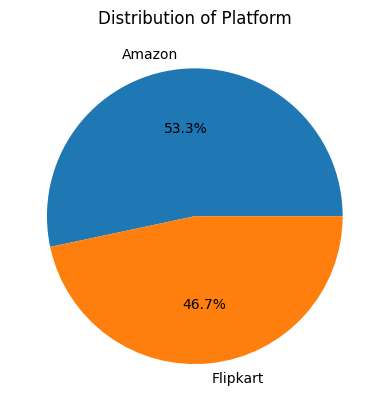

In [17]:
## Distribution of data after data processing
plt.pie(Dataframe["Platform"].value_counts(),labels=["Amazon","Flipkart"],autopct='%1.1f%%')
plt.title("Distribution of Platform")
plt.plot()

## Perform NLP for Product Matching

In [19]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\trish\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\trish\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
import string
nltk.download("stopwords")
from nltk.corpus import stopwords
stopword=set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\trish\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
## Function to clean the text
import re
def clean_text(text):
    text=text.lower() # lowercase the text
    text = re.sub(r'[^a-z0-9\s]', ' ', text) # remove special character
    words=text.split()
    word=[]
    for w in words:
        if w not in stopword and w not in string.punctuation :
            word.append(w)
    text= " ".join(word)
    text = re.sub(r'\s+', ' ', text).strip()   # normalize spaces
    return text

In [24]:
# Clean the title and category column
Dataframe["Title"]=Dataframe["Title"].apply(clean_text)
Dataframe["Category"]=Dataframe["Category"].apply(clean_text)


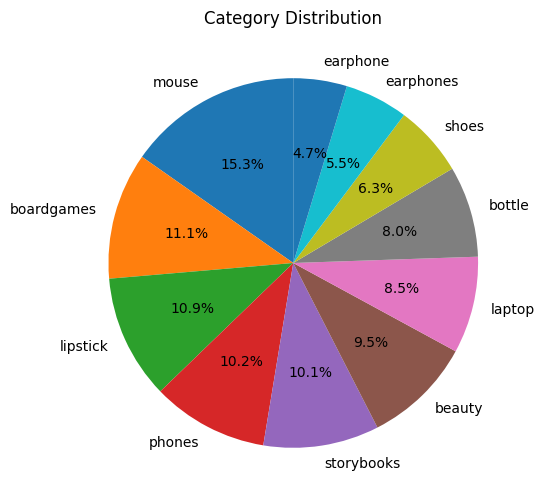

In [25]:
# Plot pie chart for Category Distribution
Category_counts = Dataframe['Category'].value_counts()
Category_counts.plot.pie(
    figsize=(6, 6),
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')  # Remove default ylabel
plt.title('Category Distribution')
plt.show()

In [28]:
## Separate the dataset of Amazon and Flipkart for placing similar product in similar column
amazon_df = Dataframe[Dataframe['Platform'] == 'Amazon'].reset_index(drop=True)
flipkart_df = Dataframe[Dataframe['Platform'] == 'Flipkart'].reset_index(drop=True)

## Product Matching 

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [31]:
# Function to extract brand and model for identifying similar product
def extract_brand(title):
     tokens = title.split()
     return tokens[0] if tokens else ""
def extract_model(title):
    tokens = title.split()
    for t in tokens:
        if any(c.isdigit() for c in t) and len(t) <= 10:
            return t
    return ""
def extract_brand_model(title):
    return extract_brand(title), extract_model(title)

In [32]:
def tfidf_matcher(a_titles, f_titles):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2),min_df=1, stop_words='english')

    titles = a_titles + f_titles
    tfidf = vectorizer.fit_transform(titles)

    a_vecs = tfidf[:len(a_titles)]
    f_vecs = tfidf[len(a_titles):]

    return cosine_similarity(a_vecs, f_vecs)

In [33]:
from rapidfuzz import fuzz
def fuzzy_score(a, b):
    return fuzz.token_set_ratio(a, b)

In [34]:
def extract_product_type(title, category):
    if category == "mouse":
        if "wired" in title:
            return "wired_mouse"
        if "bluetooth" in title or "wireless" in title:
            return "wireless_mouse"
        return "mouse"

    if category == "phone":
        return "phone"

    if category == "laptop":
        return "laptop"

    if category in ["boardgames", "toys"]:
        return "game"

    if category == "bottle":
        return "bottle"

    return category


In [35]:
def hard_rule_pass(category, brand_match, model_match):
    if category in ["phone", "laptop"]:
        return brand_match and model_match
    if category in ["mouse"]:
        return brand_match 

    return True


In [36]:
## Siamese Network
from sentence_transformers import SentenceTransformer, util

# Load Siamese (Sentence-BERT) model
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")
def semantic_similarity(a_titles, f_titles):
    a_emb = semantic_model.encode(a_titles, convert_to_tensor=True, show_progress_bar=False)
    f_emb = semantic_model.encode(f_titles, convert_to_tensor=True, show_progress_bar=False)

    return util.cos_sim(a_emb, f_emb).cpu().numpy()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [37]:
# This function contains combine Fuzzy logic + TF_IDF Cosine Similarity + Siamese Network
def hybrid_match(amazon_df, flipkart_df ):
      matches = []
      amazon_titles=amazon_df["Title"].astype(str).tolist()
      flipkart_titles=flipkart_df["Title"].astype(str).tolist()
      ## TFIDF calculation
      cosine_scores = tfidf_matcher(amazon_titles, flipkart_titles)
      ## Semantic matrices
      semantic_sim = semantic_similarity(amazon_titles, flipkart_titles)
    
      for i, a_row in amazon_df.iterrows():  
        a_title = a_row["Title"]
        a_category = a_row["Category"]
        ### best product by semantic similarity
        best_j = semantic_sim[i].argmax()  
    
        f_row = flipkart_df.iloc[best_j]
        f_title = f_row["Title"] 
        f_category = f_row["Category"]
          
        cos_score = float(cosine_scores[i][best_j])
        sem_score = float(semantic_sim[i][best_j])
        fz_score = float(fuzzy_score(a_title, f_title))/100
         
          
        brand_a, model_a = extract_brand_model(a_title)
        brand_f, model_f = extract_brand_model(f_title)
          
        brand_match = brand_a == brand_f and brand_a != ""
        model_match = model_a == model_f and model_a != ""

        product_a = extract_product_type(a_title,a_category)
        product_f = extract_product_type(f_title,f_category)

        # FINAL DECISION LOGIC
        if product_a != product_f:
            confidence="LOW"
            continue
        if not hard_rule_pass(a_category,brand_match,model_match):
            confidence='LOW'
        else:
            # Electronics (strict)
            if a_category in ["phone", "laptop"]:
                if brand_match and model_match and sem_score >= 0.75:
                    confidence = "HIGH"
                elif sem_score >= 0.78 and fz_score >= 0.80:
                    confidence = "MEDIUM"
                else:
                    confidence = "LOW"

            # Accessories (loose)
            elif a_category in ["mouse", "bottle", "shoes"]:
                if brand_match and sem_score >= 0.70 and fz_score >= 0.75:
                    confidence = "HIGH"
                elif sem_score >= 0.65 and fz_score >= 0.70:
                    confidence = "MEDIUM"
                else:
                    confidence = "LOW"

            # Beauty + books (brand optional)
            else:
                if sem_score >= 0.75 and fz_score >= 0.80:
                    confidence = "HIGH"
                elif sem_score >= 0.65 and fz_score >= 0.70:
                    confidence = "MEDIUM"
                else:
                    confidence = "LOW"
        matches.append({
            "amazon_title": a_title,
            "amazon_selling_price": a_row.get("Offer_price"),
            "amazon_price": a_row.get("Real_price"),
            "amazon_rating": a_row.get("Rating"),
            "amazon_reviews":a_row.get("Review"),
            "amazon_discount":a_row.get("Discount"),
            "Category": a_row.get("Category"),
            "flipkart_title": f_title,
            "flipkart_selling_price": f_row.get("Offer_price"),
            "flipkart_price":f_row.get("Real_price"),
            "flipkart_rating": f_row.get("Rating"),
            "flipkart_reviews":f_row.get("Review"),
            "flipkart_discount":f_row.get("Discount"),
            "brand_match": brand_a == brand_f,
            "model_match": model_a == model_f,
            "semantic_score": round(float(sem_score), 3),
            "tfidf_score": round(float(cos_score), 3),
            "fuzzy_score": round(float(fz_score), 3),
            "confidence": confidence
            
        })

      return matches

In [38]:
# Appply hybrid function on both dataset
match_list=hybrid_match(amazon_df,flipkart_df)

In [39]:
len(match_list)

2508

In [40]:
match_list[107]

{'amazon_title': 'sugar cosmetics mettle matte liquid lipstick women highly pigmented transferproof long lasting 7ml 01 lyra cool toned plum',
 'amazon_selling_price': 936.0,
 'amazon_price': 1199.0,
 'amazon_rating': 3.4,
 'amazon_reviews': 99.0,
 'amazon_discount': 22.0,
 'Category': 'lipstick',
 'flipkart_title': 'beauty berry velvet waterproof non transfer long lasting matte liquid lipstick women',
 'flipkart_selling_price': 161.0,
 'flipkart_price': 299.0,
 'flipkart_rating': 3.8,
 'flipkart_reviews': 6869.0,
 'flipkart_discount': 46.0,
 'brand_match': False,
 'model_match': False,
 'semantic_score': 0.78,
 'tfidf_score': 0.171,
 'fuzzy_score': 0.645,
 'confidence': 'LOW'}

In [41]:
# Creating DataFrame
comparison=pd.DataFrame(match_list,columns=["amazon_title","amazon_selling_price","amazon_price","amazon_rating","amazon_reviews","amazon_discount","flipkart_title","flipkart_selling_price","flipkart_price","flipkart_rating","flipkart_reviews","flipkart_discount","category","confidence"])

In [42]:
comparison["confidence"].value_counts()

confidence
LOW       1773
HIGH       428
MEDIUM     307
Name: count, dtype: int64

In [43]:
def filter_match(match_list):
    return [m for m in match_list if m["confidence"] != "LOW"]
matches = filter_match(match_list)


In [44]:
len(matches)

735

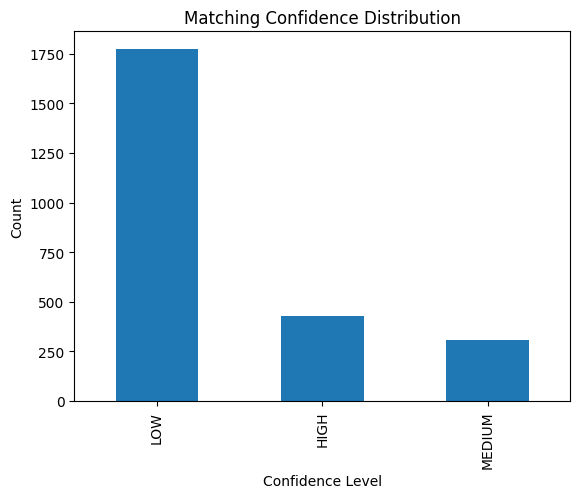

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

pd.Series([m["confidence"] for m in match_list]).value_counts().plot(kind="bar")
plt.title("Matching Confidence Distribution")
plt.xlabel("Confidence Level")
plt.ylabel("Count")
plt.show()

In [46]:
### Assign Dynamic weight to different categories
def get_weights(price):
    if price >= 20000:   # phone, laptop
        return 0.55, 0.25, 0.10, 0.10   # rating, price, reviews, discount
    else:                # accessories
        return 0.30, 0.50, 0.10, 0.10

In [47]:
import math
def convert_float(x,default=0.0):
    try:
        return float(x)
    except:
        return default

In [48]:
def normalize_review(r):
    r= max(0,convert_float(r))
    return math.log1p(r)
def ratio_score(a,b):
    return a / (a + b + 1e-9)

In [49]:
# Rule Based approch to generate pseudo-label
def select_best(match):
    amazon_price= convert_float(match["amazon_selling_price"])
    flipkart_price= convert_float(match["flipkart_selling_price"])

    amazon_rating= convert_float(match["amazon_rating"])
    flipkart_rating= convert_float(match["flipkart_rating"])

    amazon_reviews   = normalize_review(match["amazon_reviews"])
    flipkart_reviews = normalize_review(match["flipkart_reviews"])

    amazon_discount   = convert_float(match["amazon_discount"])
    flipkart_discount = convert_float(match["flipkart_discount"])

    rating_w, price_w, review_w, discount_w = get_weights(min(amazon_price, flipkart_price))
    # --- Price score (lower price = higher score) ---
    amazon_price_score   = ratio_score(flipkart_price, amazon_price)
    flipkart_price_score = ratio_score(amazon_price, flipkart_price)
    # --- Review score (higher reviews = higher score) ---
    amazon_review_score   = ratio_score(amazon_reviews, flipkart_reviews)
    flipkart_review_score = ratio_score(flipkart_reviews, amazon_reviews)
    # --- Discount score (higher discount = higher score) ---
    amazon_discount_score   = ratio_score(amazon_discount, flipkart_discount)
    flipkart_discount_score = ratio_score(flipkart_discount, amazon_discount)
        # --- Rating score: normalized ---
    amazon_rating_score = amazon_rating / 5
    flipkart_rating_score = flipkart_rating / 5
   
    amazon_score = (
        rating_w * amazon_rating_score +
        price_w * amazon_price_score +
        review_w * amazon_review_score +
        discount_w * amazon_discount_score
    )

    flipkart_score = (
        rating_w * flipkart_rating_score +
        price_w * flipkart_price_score +
        review_w * flipkart_review_score +
        discount_w * flipkart_discount_score
    )
    if amazon_score > flipkart_score:
        return "Amazon", round(amazon_score, 3), round(flipkart_score, 3)
    else:
        return "Flipkart", round(flipkart_score, 3), round(amazon_score, 3)

In [50]:
def apply_comparison(trusted_matches):
    results = []

    for match in trusted_matches:
        best, a_score, f_score = select_best(match)

        results.append({
            **match,
            "best_site": best,
            "amazon_score": a_score,
            "flipkart_score": f_score
        })

    return results

In [51]:
len(matches)

735

In [52]:
final_results = apply_comparison(matches)

## Final Dataset

In [54]:
new_df= pd.DataFrame(final_results,columns=["amazon_title",'amazon_selling_price','amazon_price','amazon_discount','amazon_rating','amazon_reviews','flipkart_title','flipkart_selling_price','flipkart_price','flipkart_discount','flipkart_rating','flipkart_reviews','Category','amazon_score',
                                           'flipkart_score','best_site'])

In [55]:
new_df.head()

,amazon_title,amazon_selling_price,amazon_price,amazon_discount,amazon_rating,amazon_reviews,flipkart_title,flipkart_selling_price,flipkart_price,flipkart_discount,flipkart_rating,flipkart_reviews,Category,amazon_score,flipkart_score,best_site
0,maybelline new york color sensational creamy m...,197.0,329.0,40.0,4.1,73073.0,maybelline new york serum lipstick matte 8hr h...,569.0,599.0,5.0,4.4,138.0,lipstick,0.776,0.434,Amazon
1,facescanada comfy matte wow liquid lipstick co...,236.0,299.0,21.0,4.2,2002.0,faces canada comfy matte wow liquid lipstick h...,236.0,299.0,21.0,4.2,45823.0,lipstick,0.611,0.593,Flipkart
2,swiss beauty pure matte creamy lipstick non dr...,172.0,229.0,25.0,4.0,6732.0,swiss beauty pure matte creamy lipstick non dr...,183.0,229.0,20.0,4.1,96691.0,lipstick,0.597,0.589,Amazon
3,lakme powerplay priming matte lipstick smooth ...,390.0,500.0,22.0,4.0,18009.0,lakm 9to5 powerplay priming matte lipstick las...,338.0,650.0,48.0,4.1,123290.0,lipstick,0.637,0.549,Flipkart
4,maybelline new york serum lipstick matte 8hr w...,569.0,599.0,5.0,4.9,1078.0,maybelline new york serum lipstick matte 8hr h...,569.0,599.0,5.0,4.4,138.0,lipstick,0.653,0.605,Amazon


In [56]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   amazon_title            735 non-null    object 
 1   amazon_selling_price    735 non-null    float64
 2   amazon_price            735 non-null    float64
 3   amazon_discount         735 non-null    float64
 4   amazon_rating           735 non-null    float64
 5   amazon_reviews          735 non-null    float64
 6   flipkart_title          735 non-null    object 
 7   flipkart_selling_price  735 non-null    float64
 8   flipkart_price          735 non-null    float64
 9   flipkart_discount       735 non-null    float64
 10  flipkart_rating         735 non-null    float64
 11  flipkart_reviews        735 non-null    float64
 12  Category                735 non-null    object 
 13  amazon_score            735 non-null    float64
 14  flipkart_score          735 non-null    fl

## Feature Engineering

In [58]:
new_df["price_difference"]=new_df["amazon_price"]-new_df["flipkart_price"]

In [59]:
new_df['price_ratio'] = new_df['flipkart_price'] / new_df['amazon_price']
new_df['discount_ratio'] = new_df['amazon_discount'] / new_df['flipkart_discount']
new_df['rating_diff'] = new_df['amazon_rating'] - new_df['flipkart_rating']
new_df['reviews_diff'] = new_df['amazon_reviews'] - new_df['flipkart_reviews']
new_df['amazon_popularity'] = new_df['amazon_rating'] * new_df['amazon_reviews']
new_df['flipkart_popularity'] = new_df['flipkart_rating'] * new_df['flipkart_reviews']
new_df['popularity_diff'] = new_df['amazon_popularity'] - new_df['flipkart_popularity']

In [61]:
## Replace infinity with 0 so that they won't affect decision 
new_df.replace([np.inf, -np.inf], np.nan, inplace=True)
new_df.fillna(0, inplace=True)

In [62]:
new_df.describe()

,amazon_selling_price,amazon_price,amazon_discount,amazon_rating,amazon_reviews,flipkart_selling_price,flipkart_price,flipkart_discount,flipkart_rating,flipkart_reviews,amazon_score,flipkart_score,price_difference,price_ratio,discount_ratio,rating_diff,reviews_diff,amazon_popularity,flipkart_popularity,popularity_diff
count,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,735.000000,7.350000e+02,735.000000
mean,11360.696599,14208.534721,32.387755,4.106259,4117.687075,10592.032653,14116.345578,36.644898,4.201905,12968.925170,0.664491,0.559706,92.189143,2.692949,1.084525,-0.095646,-8851.238095,16931.934150,5.495010e+04,-38018.169252
std,24837.297344,31034.623596,20.390616,0.358872,13063.121381,23076.907231,30580.250287,21.993259,0.258209,35652.512512,0.055474,0.067945,12294.888452,24.550389,0.981016,0.380567,34831.646876,53640.105703,1.519851e+05,148934.379912
min,0.000000,0.000000,0.000000,1.000000,0.000000,65.000000,115.000000,0.000000,2.700000,0.000000,0.543000,0.290000,-149888.888889,0.000000,0.000000,-3.000000,-209286.000000,0.000000,0.000000e+00,-941853.800000
25%,319.500000,499.000000,16.000000,4.000000,86.000000,279.000000,599.000000,18.500000,4.000000,0.000000,0.621000,0.524000,-174.000000,0.875700,0.645161,-0.300000,-2788.000000,353.750000,0.000000e+00,-12141.500000
50%,683.000000,1135.000000,28.000000,4.100000,508.000000,599.000000,1199.000000,33.000000,4.200000,31.000000,0.654000,0.564000,0.000000,1.000000,1.000000,-0.100000,39.000000,2111.500000,1.295000e+02,159.100000
75%,4268.500000,4899.000000,46.500000,4.300000,2072.000000,2044.000000,4249.500000,52.000000,4.400000,4506.000000,0.701000,0.593000,199.000000,1.129916,1.166667,0.100000,861.000000,8346.200000,1.801200e+04,3515.400000
max,154900.000000,209890.000000,89.000000,5.000000,158992.000000,134900.000000,164999.000000,89.000000,5.000000,248435.000000,0.920000,0.738000,98000.000000,614.615385,10.000000,1.300000,148277.000000,660332.400000,1.068270e+06,621868.900000


In [64]:
## Chi-square test 
ct = pd.crosstab(new_df['best_site'],new_df['Category'])
from scipy.stats import chi2_contingency
chi2_contingency(ct)


Chi2ContingencyResult(statistic=128.7339779321361, pvalue=5.176115854247336e-24, dof=8, expected_freq=array([[19.69795918, 46.13469388, 30.58367347, 45.09795918, 67.90612245,
        66.86938776, 49.24489796, 40.95102041, 14.51428571],
       [18.30204082, 42.86530612, 28.41632653, 41.90204082, 63.09387755,
        62.13061224, 45.75510204, 38.04897959, 13.48571429]]))

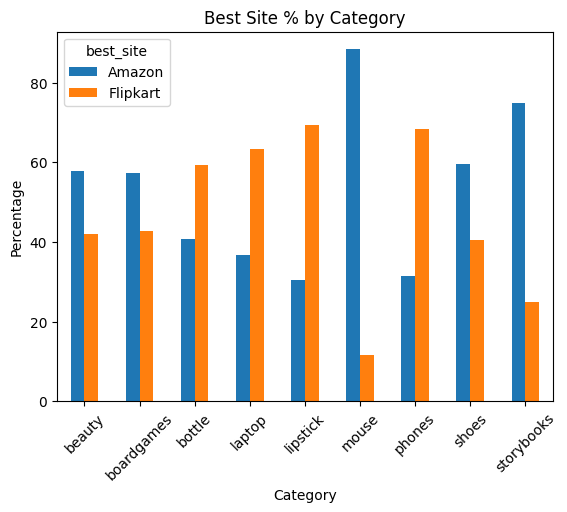

In [65]:
import matplotlib.pyplot as plt
pct = ct.div(ct.sum(axis=0), axis=1) * 100
pct = pct.round(2)
pct.T.plot(kind="bar")
plt.ylabel("Percentage")
plt.title("Best Site % by Category")
plt.xticks(rotation=45)
plt.show()

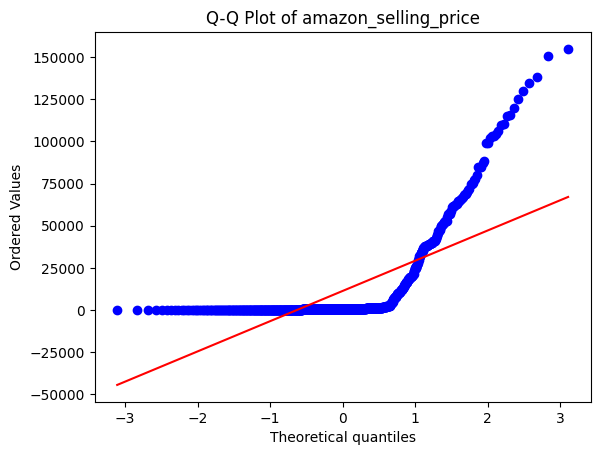

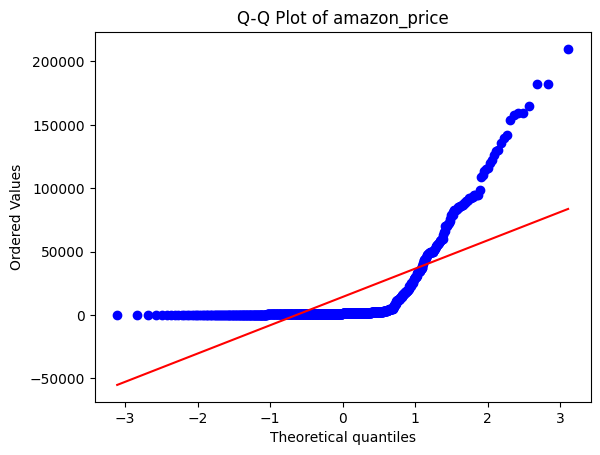

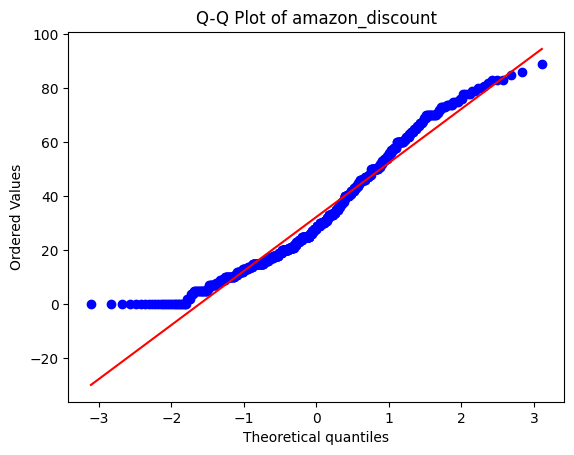

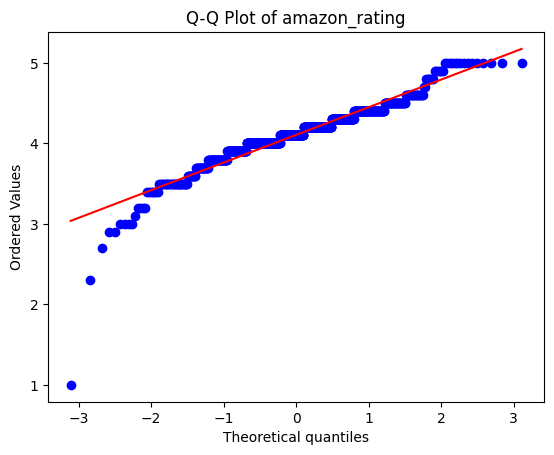

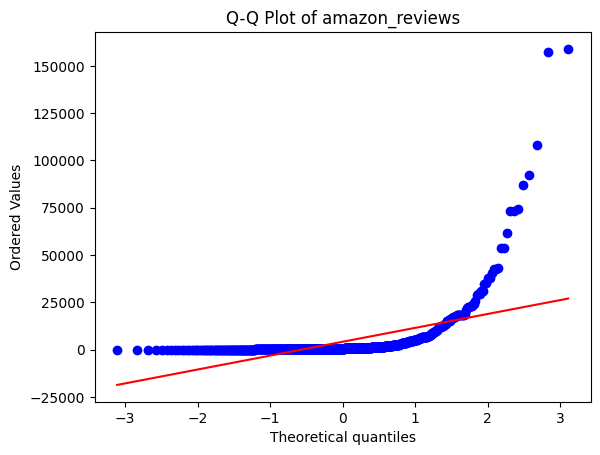

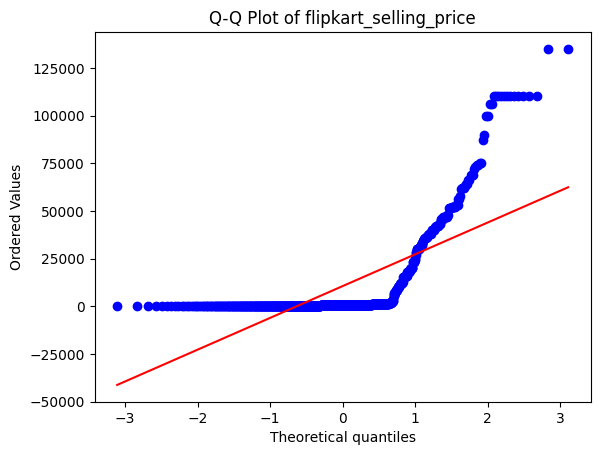

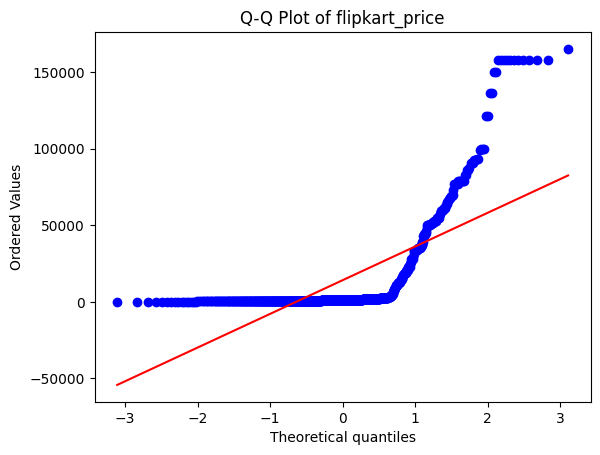

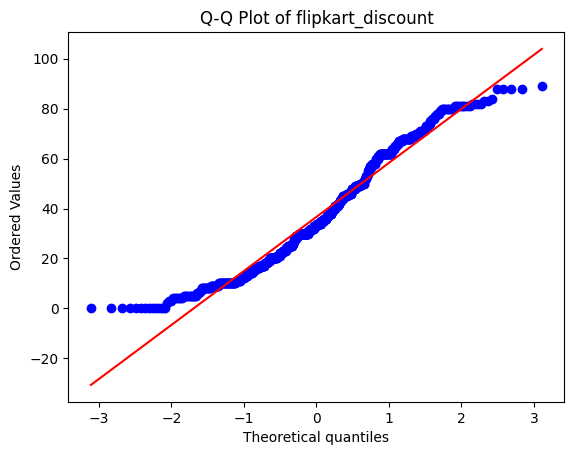

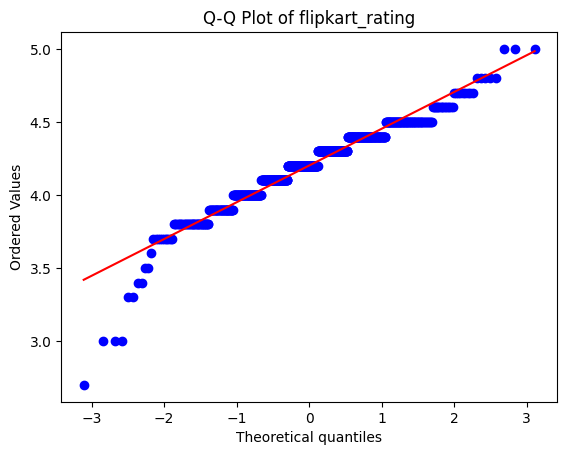

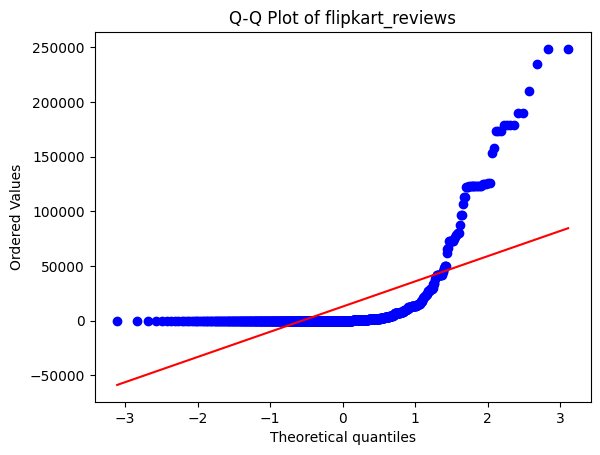

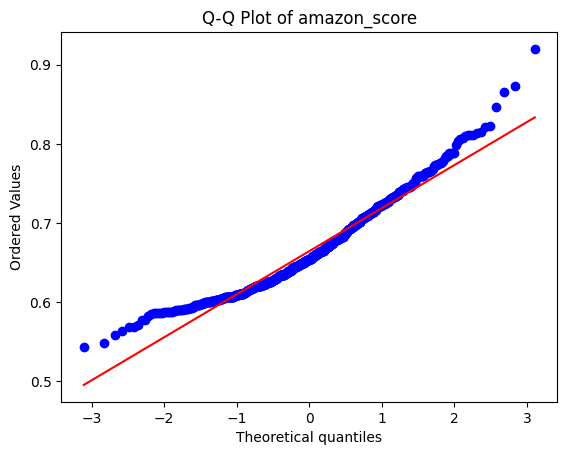

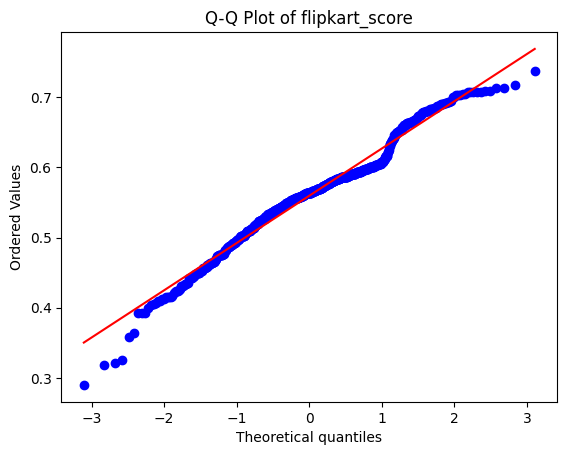

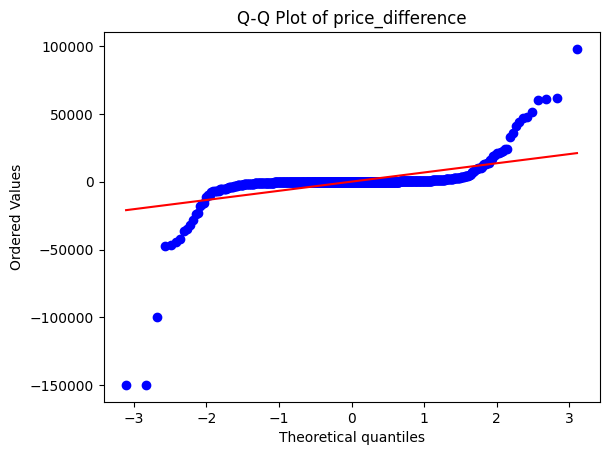

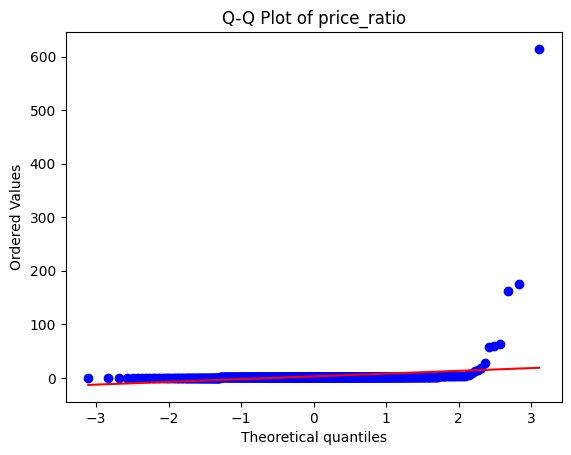

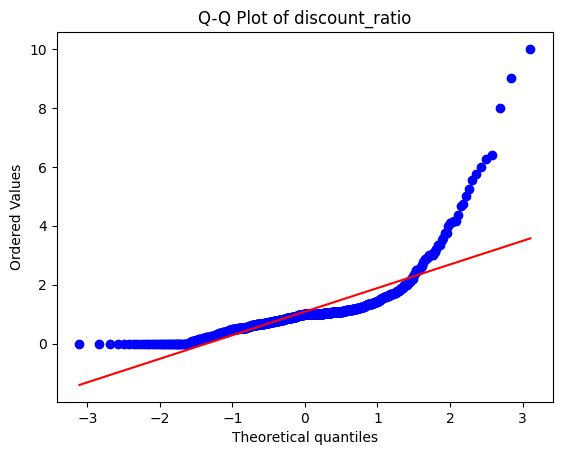

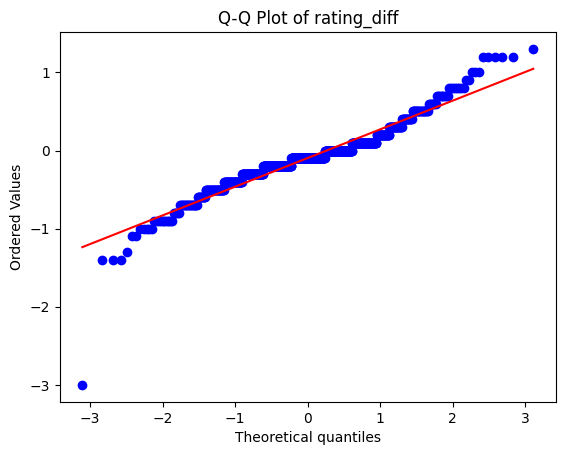

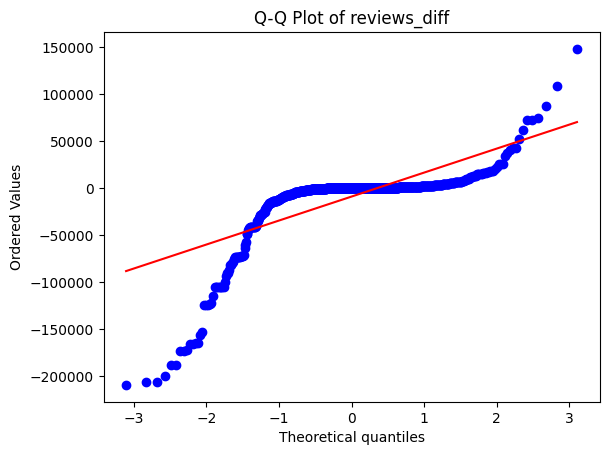

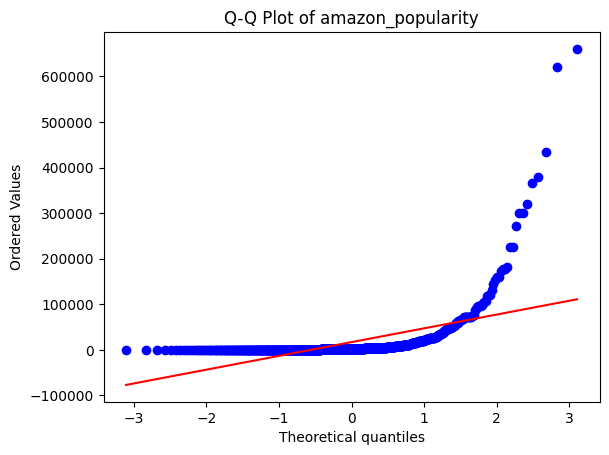

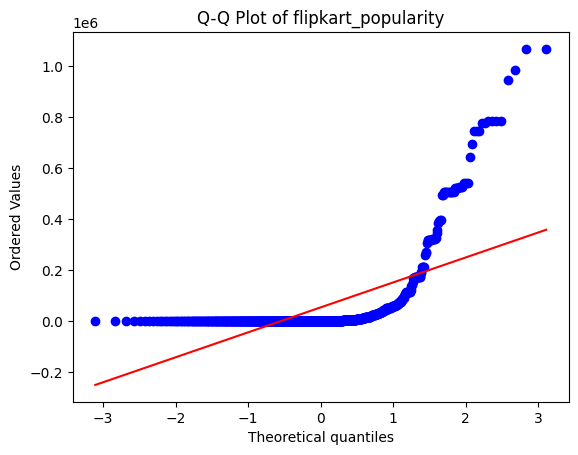

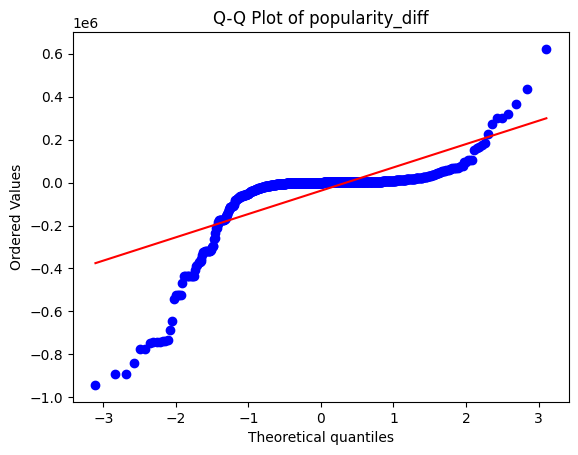

In [66]:
import scipy.stats as stats
col = "amazon_selling_price"   # change column
num_cols = new_df.select_dtypes(include=["int64", "float64"]).columns
for col in num_cols:
 stats.probplot(new_df[col].dropna(), dist="norm", plot=plt)
 plt.title(f"Q-Q Plot of {col}")
 plt.show()

In [67]:
new_df=new_df.drop(["amazon_title","flipkart_title","amazon_score","flipkart_score"],axis=1)

In [70]:
new_df['discount_effect_diff'] = new_df['amazon_discount'] - new_df['flipkart_discount']

In [72]:
# Final features to be included in dataset for ML model
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   amazon_selling_price    735 non-null    float64
 1   amazon_price            735 non-null    float64
 2   amazon_discount         735 non-null    float64
 3   amazon_rating           735 non-null    float64
 4   amazon_reviews          735 non-null    float64
 5   flipkart_selling_price  735 non-null    float64
 6   flipkart_price          735 non-null    float64
 7   flipkart_discount       735 non-null    float64
 8   flipkart_rating         735 non-null    float64
 9   flipkart_reviews        735 non-null    float64
 10  Category                735 non-null    object 
 11  best_site               735 non-null    object 
 12  price_difference        735 non-null    float64
 13  price_ratio             735 non-null    float64
 14  discount_ratio          735 non-null    fl

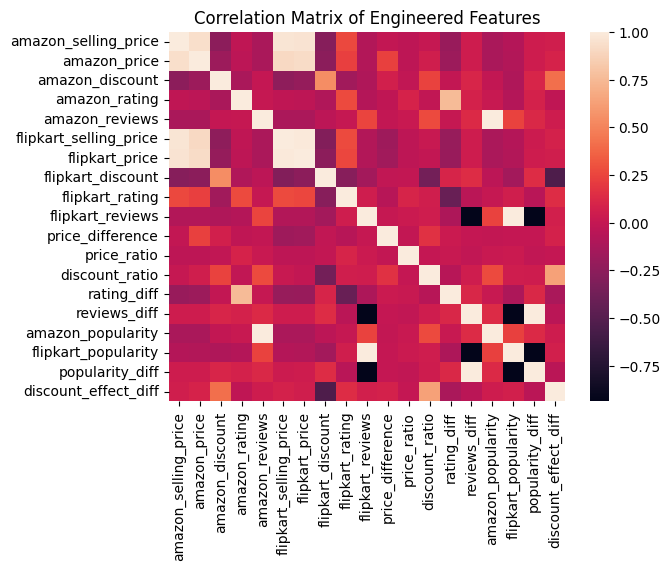

In [73]:
import seaborn as sns

plt.figure()
sns.heatmap(new_df.corr(numeric_only=True), annot=False)
plt.title("Correlation Matrix of Engineered Features")
plt.show()

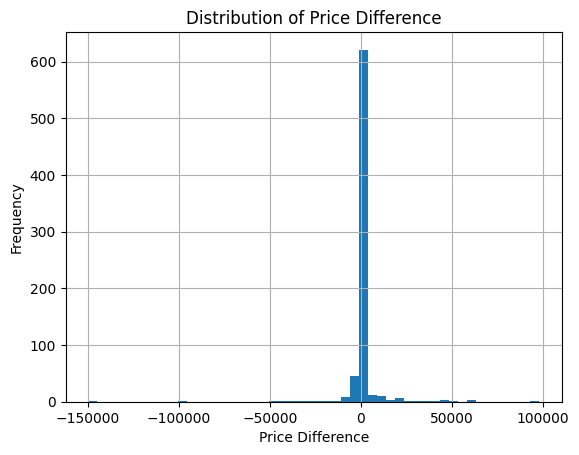

In [74]:
plt.figure()
new_df["price_difference"].hist(bins=50)
plt.title("Distribution of Price Difference")
plt.xlabel("Price Difference")
plt.ylabel("Frequency")
plt.show()

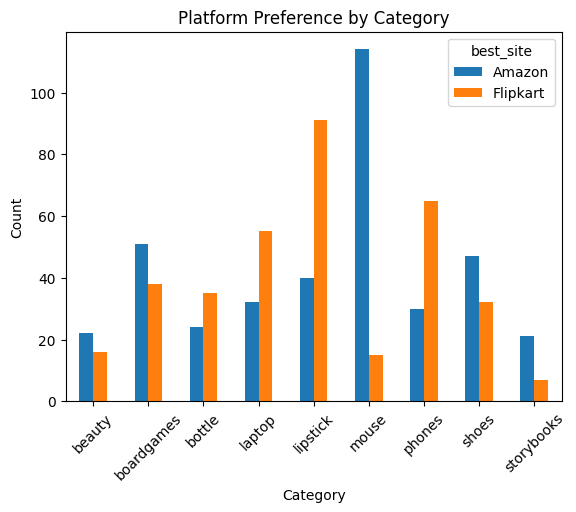

In [75]:
import pandas as pd

ct = pd.crosstab(new_df['Category'], new_df['best_site'])
ct.plot(kind='bar')

plt.title("Platform Preference by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

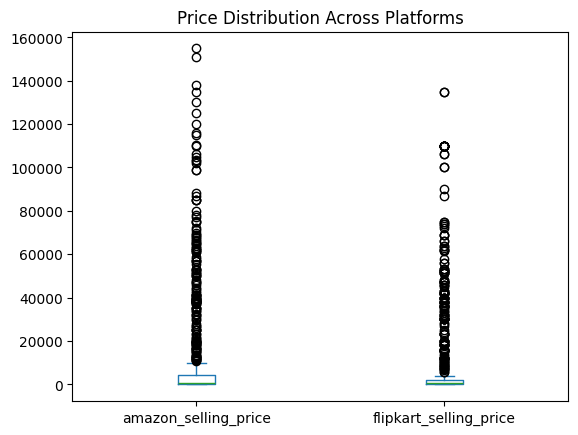

In [76]:
plt.figure()
new_df[["amazon_selling_price", "flipkart_selling_price"]].plot(kind='box')
plt.title("Price Distribution Across Platforms")
plt.show()

In [77]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
new_df["best_site"]=le.fit_transform(new_df["best_site"])

In [81]:
# Splitting dataset into input feature and target variable
X=new_df.drop("best_site",axis=1)
y=new_df["best_site"]

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import AdaBoostClassifier

In [83]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state= 2,stratify=y)

In [85]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

In [86]:
X_train.shape

(551, 20)

In [87]:
column= ColumnTransformer(transformers=[("tf1",OneHotEncoder(handle_unknown="ignore",sparse_output=False),[10]),
                                      ("tf2",StandardScaler(),num_cols)])

In [88]:
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [89]:
## Train different Base Model

In [90]:
ada_pipe=Pipeline([("preprocess",column),
                  ("model",AdaBoostClassifier(n_estimators=370, learning_rate=0.3,random_state=42))])

In [91]:
ada_pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('tf1',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [10]),
                                                 ('tf2', StandardScaler(),
                                                  Index(['amazon_selling_price', 'amazon_price', 'amazon_discount',
       'amazon_rating', 'amazon_reviews', 'flipkart_selling_price',
       'flipkart_price', 'flipkart_discount', 'flipkart_rating',
       'flipkart_reviews', 'price_difference', 'price_ratio', 'discount_ratio',
       'rating_diff', 'reviews_diff', 'amazon_popularity',
       'flipkart_popularity', 'popularity_diff', 'discount_effect_diff'],
      dtype='object'))])),
                ('model',
                 AdaBoostClassifier(learning_rate=0.3, n_estimators=370,
                                    random_state=42))])

In [92]:
y_pred=ada_pipe.predict(X_train)

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
acc = accuracy_score(y_train, y_pred)
prec = precision_score(y_train, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_train, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_train, y_pred, average="weighted", zero_division=0)
print(acc,prec,rec,f1)

1.0 1.0 1.0 1.0


In [94]:
y_pred1=ada_pipe.predict(X_test)

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
acc = accuracy_score(y_test, y_pred1)
prec = precision_score(y_test, y_pred1, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred1, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred1, average="weighted", zero_division=0)
print(acc,prec,rec,f1)

0.8913043478260869 0.8914125411521042 0.8913043478260869 0.8912528820816865


In [96]:
from sklearn.linear_model import LogisticRegression,RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC,LinearSVC
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis,LinearDiscriminantAnalysis

In [97]:
classifiers = {
    "Logistic Regression":Pipeline([("preprocess",column),("model",LogisticRegression(max_iter=1000))]),
    "Ridge Classifier":Pipeline([("preprocess",column),
                    ("model",RidgeClassifier())]),
    "Decision Tree": Pipeline([("preprocess",column),
                  ("model",DecisionTreeClassifier())]),
    "Random Forest": Pipeline([("preprocess",column),
                  ("model",RandomForestClassifier())]),
    "Extra Trees":Pipeline([("preprocess",column),
                  ("model",ExtraTreesClassifier())]),
    "Bagging":Pipeline([("preprocess",column),
                  ("model",BaggingClassifier())]),
    "Gradient Boosting": Pipeline([("preprocess",column),
                  ("model",GradientBoostingClassifier())]),
    "Support Vector Machine": Pipeline([("preprocess",column),
                  ("model",SVC())]),
    "Linear SVC":Pipeline([("preprocess",column),
                  ("model",LinearSVC(max_iter =10000))]),
    "Naive Bayes": Pipeline([("preprocess",column),
                  ("model",GaussianNB())]),
    # "Multinomial Bayes": Pipeline([("preprocess",column),
                  # ("model",MultinomialNB())]),
    "Bernoulli Bayes": Pipeline([("preprocess",column),
                  ("model",BernoulliNB())]),
    "K-Nearest Neighbors": Pipeline([("preprocess",column),
                  ("model",KNeighborsClassifier())]) ,
    "MLP Classifier": Pipeline([("preprocess",column),
                  ("model",MLPClassifier(max_iter=1000))]),
    "Linear Discrimintant Analysis": Pipeline([("preprocess",column),
                  ("model",LinearDiscriminantAnalysis())]),
    "Quadratic Discrimintant Analysis": Pipeline([("preprocess",column),
                  ("model",QuadraticDiscriminantAnalysis())]),
    "Adaboost":Pipeline([("preprocess",column),
                  ("model",AdaBoostClassifier(n_estimators=370, learning_rate=0.3,random_state=42))])
}

In [98]:
results = []

In [99]:
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred, average='weighted'),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

D:\New\Python\Path\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
D:\New\Python\Path\Python312\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


                               Model  Accuracy  F1 Score  Precision    Recall  \
0                Logistic Regression  0.777174  0.777233   0.777706  0.777174   
1                   Ridge Classifier  0.733696  0.733263   0.738108  0.733696   
2                      Decision Tree  0.853261  0.853300   0.853793  0.853261   
3                      Random Forest  0.869565  0.869411   0.870082  0.869565   
4                        Extra Trees  0.864130  0.864022   0.864374  0.864130   
5                            Bagging  0.853261  0.852864   0.854962  0.853261   
6                  Gradient Boosting  0.891304  0.891176   0.891893  0.891304   
7             Support Vector Machine  0.798913  0.798871   0.798877  0.798913   
8                         Linear SVC  0.755435  0.755240   0.758673  0.755435   
9                        Naive Bayes  0.690217  0.690263   0.691329  0.690217   
10                   Bernoulli Bayes  0.728261  0.727939   0.728307  0.728261   
11               K-Nearest N

In [101]:
##Introduction of Stacking Classifier with different base model

In [102]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ('rf', RandomForestClassifier(n_estimators=200)),
    ('gb', GradientBoostingClassifier(n_estimators=300)),
    ('svc', SVC(probability=True))
]

stacking = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
model = Pipeline([
    ('preprocessing', column),
    ('stacking', stacking)
])
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('tf1',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [10]),
                                                 ('tf2', StandardScaler(),
                                                  Index(['amazon_selling_price', 'amazon_price', 'amazon_discount',
       'amazon_rating', 'amazon_reviews', 'flipkart_selling_price',
       'flipkart_price', 'flipkart_discount', 'flipkart_rating',
       'flipkart_rev...o',
       'rating_diff', 'reviews_diff', 'amazon_popularity',
       'flipkart_popularity', 'popularity_diff', 'discount_effect_diff'],
      dtype='object'))])),
                ('stacking',
                 StackingClassifier(estimators=[('rf',
                                                 RandomForestClassifier(n_estimators=200)),
                                                ('gb',
                                                 GradientBoostingClassifier(n_estimators=300)),
                                                ('svc', SVC(probability=True))],
                                    final_estimator=LogisticRegression()))])

In [103]:
y_pred=model.predict(X_train)

In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
acc = accuracy_score(y_train, y_pred)
prec = precision_score(y_train, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_train, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_train, y_pred, average="weighted", zero_division=0)
print(acc,prec,rec,f1)

1.0 1.0 1.0 1.0


In [105]:
y_pred1=model.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
acc = accuracy_score(y_test, y_pred1)
prec = precision_score(y_test, y_pred1, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred1, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred1, average="weighted", zero_division=0)
print(acc,prec,rec,f1)

0.8913043478260869 0.8914125411521042 0.8913043478260869 0.8912528820816865


In [107]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
pipeline = Pipeline([("preprocess",column),("xgb",xgb.XGBClassifier(
    bjective='binary:logistic',  # or 'multi:softmax' for multi-class
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
))])
param_grid = {
    'xgb__n_estimators': [200, 400, 600],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 0.9, 1],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9, 1],
    'xgb__gamma': [0, 0.1, 0.2],
    'xgb__reg_alpha': [0, 0.01, 0.1],
    'xgb__reg_lambda': [1, 1.5, 2]
}
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1_weighted',
    cv=5,
    verbose=1,
    n_jobs=-1
)
random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("CV F1 score:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


D:\New\Python\Path\Python312\site-packages\xgboost\training.py:183: UserWarning: [10:08:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "bjective", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 1, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 200, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 0.7}
CV F1 score: 0.9110250172060823


In [108]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_pred = random_search.best_estimator_.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9021739130434783
Test F1: 0.9021970315799208
Confusion Matrix:
 [[84 11]
 [ 7 82]]


In [112]:
from sklearn.model_selection import cross_val_score

In [117]:
from xgboost import XGBClassifier
# -------------------------------
# 3️⃣ Base Models
# -------------------------------
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=600,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.7,
    gamma=0.2,
    reg_alpha=0,
    reg_lambda=2,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1,
    passthrough=True
)
pipeline = Pipeline([
    ('preprocess', column),
    ('stack', stacking_model)
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(scores)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[0.88288288 0.86363636 0.9        0.91818182 0.91818182]
Test Accuracy: 0.9184782608695652
Test F1 Score: 0.9184903092481427
Confusion Matrix:
 [[87  8]
 [ 7 82]]


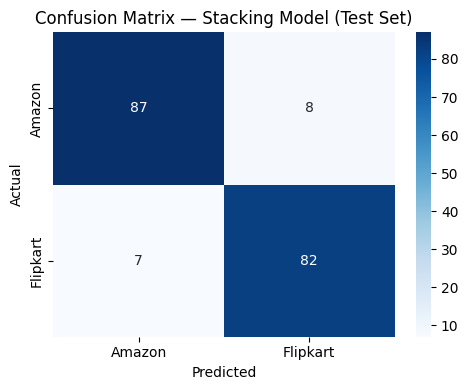

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Amazon', 'Flipkart'],
            yticklabels=['Amazon', 'Flipkart'])
plt.title('Confusion Matrix — Stacking Model (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_stacking.png', dpi=150)
plt.show()

In [114]:
y_pred_1 = pipeline.predict(X_train)

print("Test Accuracy:", accuracy_score(y_train, y_pred_1))
print("Test F1 Score:", f1_score(y_train, y_pred_1, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_1))

Test Accuracy: 1.0
Test F1 Score: 1.0
Confusion Matrix:
 [[286   0]
 [  0 265]]


In [115]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=500,
    max_depth=3,
    learning_rate=0.07,
    subsample=0.85,
    colsample_bytree=0.7,
    gamma=0.2,
    reg_alpha=0,
    reg_lambda=3,
    random_state=42
)
ada_model = AdaBoostClassifier(
    n_estimators=370,
    learning_rate=0.3,
    random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model),
        ('gb', gb_model),
        ("ada",ada_model)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# -------------------------------
# Full Pipeline
# -------------------------------
pipeline = Pipeline([
    ('preprocess', column),
    ('stack', stacking_model)
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(scores)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

[0.87387387 0.87272727 0.89090909 0.91818182 0.91818182]
Test Accuracy: 0.9130434782608695
Test F1 Score: 0.9130640353582075
Confusion Matrix:
 [[86  9]
 [ 7 82]]


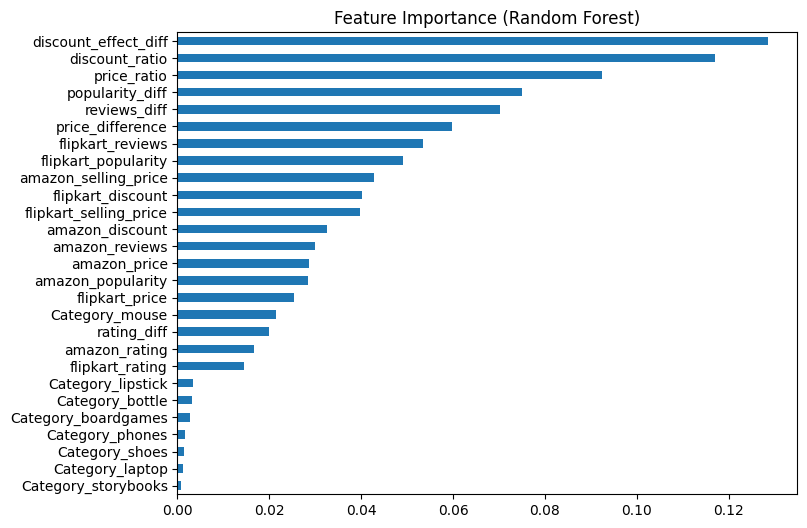

In [116]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Convert categorical
X_encoded = pd.get_dummies(X, drop_first=True)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y)

importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X_encoded.columns)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.show()

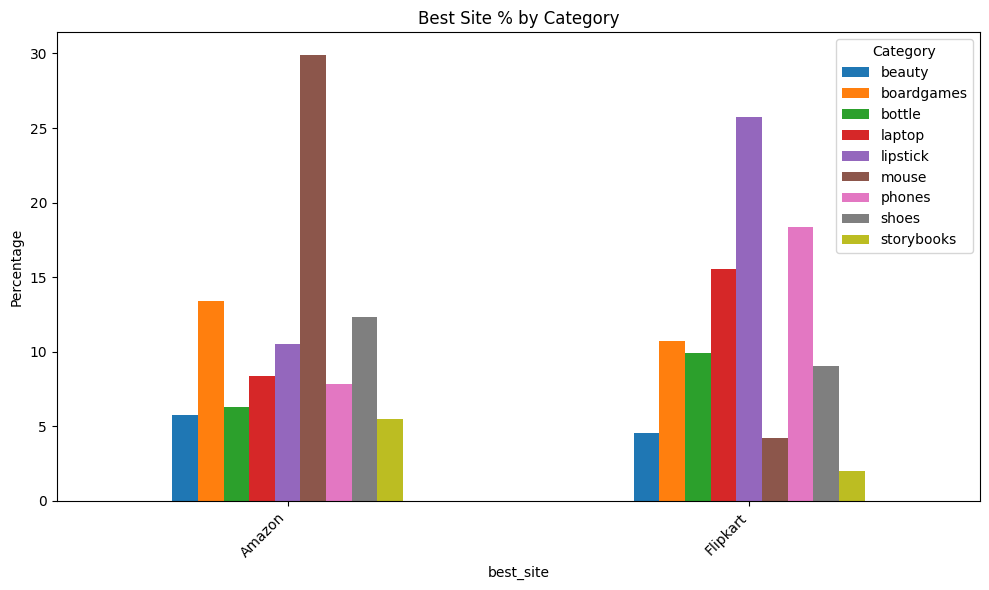

In [110]:
import matplotlib.pyplot as plt

# Drop the 'All' margin column if it exists
if 'All' in ct.columns:
    ct_clean = ct.drop(columns=['All'])
else:
    ct_clean = ct.copy()

# Also drop 'All' from index if it exists (row margin)
if 'All' in ct_clean.index:
    ct_clean = ct_clean.drop(index=['All'])

pct = ct_clean.div(ct_clean.sum(axis=0), axis=1) * 100
pct = pct.round(2)

pct.T.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Percentage")
plt.title("Best Site % by Category")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Category")
plt.tight_layout()
plt.show()